In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

Multiprocessing: Below initialize julia on 7 cores

In [32]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([16, 17, 18, 19, 20, 21, 22], dtype=int64)

In [95]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")

<PyCall.jlwrap non_singular_sigma_χ>

In [99]:
EEC=np.array([0.272,0.299,0.329,0.365,0.410,0.457,0.521,0.595,0.682,0.783,0.906,1.049,1.19,1.31,1.34,1.12,0.46])
χ_list=np.pi*np.array([150.3,152.1,153.9,155.7,157.5,159.3,161.1,162.9,164.7,166.5,168.3,170.1,171.9,173.7,175.5,177.3,179.1])/180

xlist = np.pi/180*np.linspace(150,179.9,num=50)
length=len(xlist)

v_1 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=1)
v_2 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)
v_3 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=3)

RuntimeError: <PyCall.jlwrap (in a Julia function called from Python)
JULIA: On worker 21:
DomainError with -0.1963492327123597:
log was called with a negative real argument but will only return a complex result if called with a complex argument. Try log(Complex(x)).
Stacktrace:
  [1] throw_complex_domainerror
    @ .\math.jl:33
  [2] _log
    @ .\special\log.jl:301
  [3] log
    @ .\special\log.jl:267
  [4] #alpha_s_func#15552
    @ c:\Users\15652\Desktop\EEC\strong coupling\alpha_s.jl:81
  [5] alpha_s_func
    @ c:\Users\15652\Desktop\EEC\strong coupling\alpha_s.jl:71 [inlined]
  [6] #γS_analytic#15400
    @ c:\Users\15652\Desktop\EEC\anomalous dim\non-cusp\gammaS.jl:109
  [7] γS_analytic
    @ c:\Users\15652\Desktop\EEC\anomalous dim\non-cusp\gammaS.jl:107 [inlined]
  [8] f
    @ c:\Users\15652\Desktop\EEC\sigma.jl:65
  [9] GaussKronrod
    @ C:\Users\15652\.julia\packages\HCubature\gOo1d\src\gauss-kronrod.jl:32
 [10] hcubature_
    @ C:\Users\15652\.julia\packages\HCubature\gOo1d\s

Close previous julias

In [17]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x000001b527839d20>

Non-singular

In [86]:
xlist = np.pi/180*np.linspace(150,179.9,num=50)
non_singular_2 = []
perturbation_2 = []
SCET_2 = []

for x in xlist:
    non_singular_2.append(Main.non_singular_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))
    perturbation_2.append(Main.perturbation_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))
    SCET_2.append(Main.SCET_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))
print(perturbation_2)

[0.23927496929199604, 0.24690461460967686, 0.25494759000798617, 0.26343378102305753, 0.2723958381359763, 0.2818694921976084, 0.2918939131119594, 0.3025121187644057, 0.31377144248800126, 0.3257240689472748, 0.33842765025211113, 0.35194601648004226, 0.36634999769325294, 0.3817183781271001, 0.39813900768194255, 0.41571010140409526, 0.4345417646031854, 0.45475779002506683, 0.4764977846152428, 0.49991969757821836, 0.5252028396130848, 0.5525515066681373, 0.582199352050913, 0.6144146906385674, 0.6495069715499433, 0.6878347255366309, 0.7298153869334136, 0.7759375163175398, 0.8267761219078421, 0.8830120135541026, 0.9454564493029666, 1.0150827889256484, 1.0930675058668742, 1.1808438058643722, 1.280172362726127, 1.3932354441729666, 1.522763102920237, 1.6722031885976494, 1.8459502658214073, 2.049650026401468, 2.2905879346216103, 2.5781280194985503, 2.9240014938429466, 3.341631757344966, 3.8413175818404737, 4.4079010425943395, 4.8945325485734035, 4.390178988814778, -5.213406797662751, -712.44096185

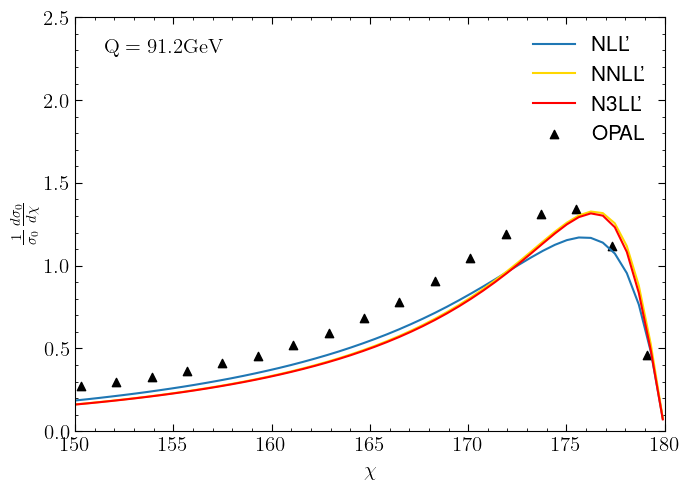

In [90]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

#ax1.plot(xlist*180/np.pi, v_2+non_singular_2, label="matched")
#ax1.plot(xlist*180/np.pi, non_singular_2, label="non-singular")
#ax1.plot(xlist*180/np.pi, SCET_2, label="SCET")
#ax1.plot(xlist*180/np.pi, perturbation_1, label="PERT(LO)")
#ax1.plot(xlist*180/np.pi, perturbation_2, label="PERT(NLO)")

ax1.plot(xlist*180/np.pi, v_1, label="NLL'")
ax1.plot(xlist*180/np.pi, v_2, label="NNLL'",color="gold")
ax1.plot(xlist*180/np.pi, v_3, label="N3LL'",color="red")
ax1.scatter(χ_list*180/np.pi, EEC, label="OPAL",marker="^",color="black")

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.05, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,2.5)
plt.xlim(150,180)

plt.tight_layout()  
plt.show()

In [48]:
EEC=np.array([0.272,0.299,0.329,0.365,0.410,0.457,0.521,0.595,0.682,0.783,0.906,1.049,1.19,1.31,1.34,1.12,0.46])
χ_list=np.pi*np.array([150.3,152.1,153.9,155.7,157.5,159.3,161.1,162.9,164.7,166.5,168.3,170.1,171.9,173.7,175.5,177.3,179.1])/180

xlist = np.pi/180*np.linspace(150,179.9,num=50)
length=len(xlist)

v_1 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=1)
v_2 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)
v_3 = Main.sigma_fast(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=3)

resum_error_1 = Main.resum_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=1)
resum_error_2 = Main.resum_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)
resum_error_3 = Main.resum_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=3)

fixed_error_1 = Main.fixed_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=1)
fixed_error_2 = Main.fixed_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)
fixed_error_3 = Main.fixed_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=3)

NP_error_1 = Main.NP_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=1)
NP_error_2 = Main.NP_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2)
NP_error_3 = Main.NP_error(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, order=3)

In [50]:
error_1 = np.sqrt(np.array(resum_error_1)**2+np.array(fixed_error_1)**2+np.array(NP_error_1)**2)
error_2 = np.sqrt(np.array(resum_error_2)**2+np.array(fixed_error_2)**2+np.array(NP_error_2)**2)
error_3 = np.sqrt(np.array(resum_error_3)**2+np.array(fixed_error_3)**2+np.array(NP_error_3)**2)

error_1_2 = np.sqrt(np.array(fixed_error_1)**2+np.array(NP_error_1)**2)
error_2_2 = np.sqrt(np.array(fixed_error_2)**2+np.array(NP_error_2)**2)
error_3_2 = np.sqrt(np.array(fixed_error_3)**2+np.array(NP_error_3)**2)

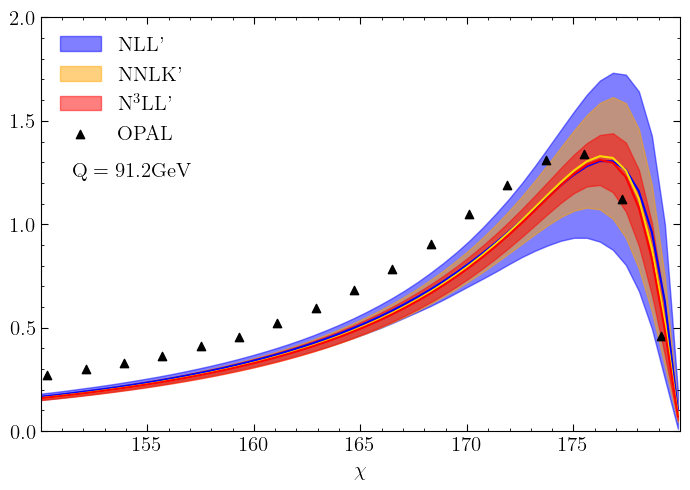

In [105]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_1, color="blue")
ax1.plot(xlist*180/np.pi, v_2, color="gold")
ax1.plot(xlist*180/np.pi, v_3, color="red")

ax1.fill_between(xlist*180/np.pi, v_1 - error_1, v_1 + error_1, color="blue", alpha=0.5,label=r"\rm NLL'")
ax1.fill_between(xlist*180/np.pi, v_2 - error_2, v_2 + error_2, color="orange", alpha=0.5,label=r"\rm NNLK'")
ax1.fill_between(xlist*180/np.pi, v_3 - error_3, v_3 + error_3, color="red", alpha=0.5,label=r"\rm $\mathrm{N}^3$LL'")

ax1.scatter(χ_list*180/np.pi, EEC, label=r"\rm OPAL",marker="^",color="black")
ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.05, 0.65,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

ax1.legend(loc='upper left', frameon=False, fontsize=sizeOfFont)

plt.ylim(0,2)
plt.xlim(150,180)
plt.yticks([0, 0.5,1.0,1.5,2.0])
plt.xticks([155,160,165,170,175])

plt.tight_layout()  
plt.show()

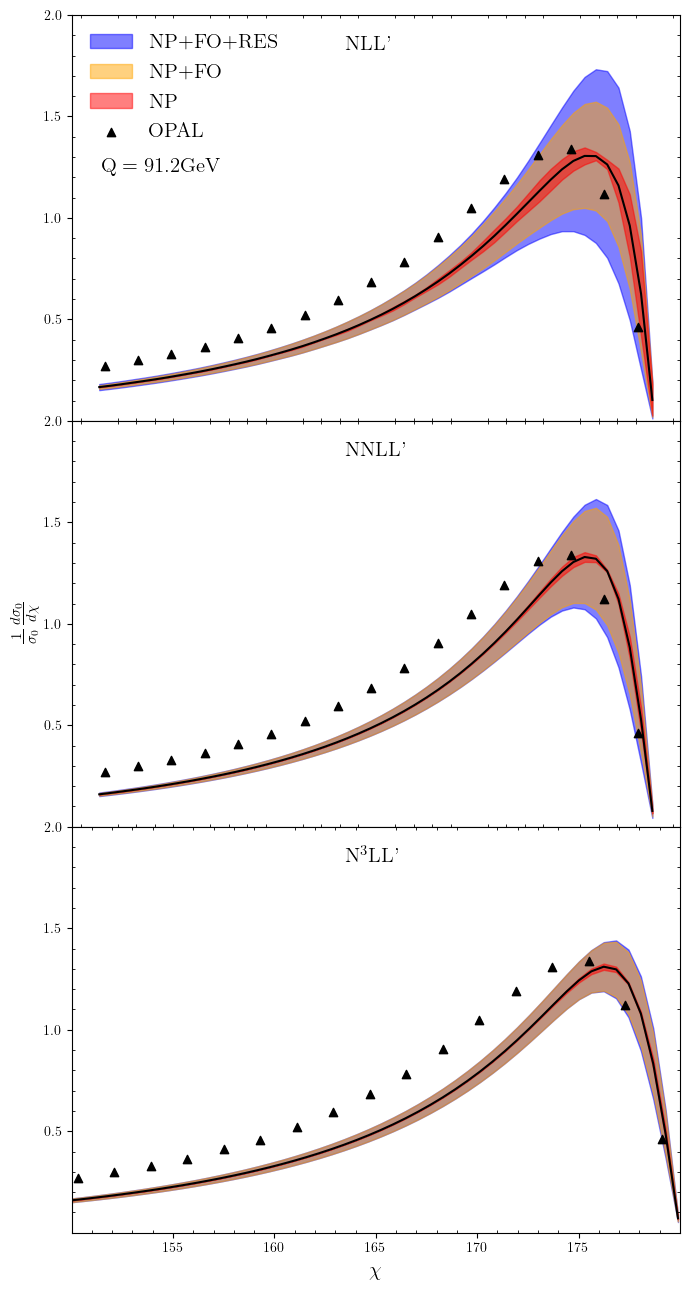

In [112]:
fig, [ax1,ax2,ax3] = plt.subplots(3, 1, figsize=(7, 13), sharey=True)

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_1, color="black")
ax1.fill_between(xlist*180/np.pi, v_1 - error_1, v_1 + error_1, color="blue", alpha=0.5, label=r"\rm NP+FO+RES")
ax1.fill_between(xlist*180/np.pi, v_1 - error_1_2, v_1 + error_1_2, color="orange", alpha=0.5, label=r"\rm NP+FO")
ax1.fill_between(xlist*180/np.pi, v_1 - NP_error_1, v_1 + NP_error_1, color="red", alpha=0.5, label=r"\rm NP")

ax2.plot(xlist*180/np.pi, v_2, color="black")
ax2.fill_between(xlist*180/np.pi, v_2 - error_2, v_2 + error_2, color="blue", alpha=0.5)
ax2.fill_between(xlist*180/np.pi, v_2 - error_2_2, v_2 + error_2_2, color="orange", alpha=0.5)
ax2.fill_between(xlist*180/np.pi, v_2 - NP_error_2, v_2 + NP_error_2, color="red", alpha=0.5)

ax3.plot(xlist*180/np.pi, v_3, color="black")
ax3.fill_between(xlist*180/np.pi, v_3 - error_3, v_3 + error_3, color="blue", alpha=0.5)
ax3.fill_between(xlist*180/np.pi, v_3 - error_3_2, v_3 + error_3_2, color="orange", alpha=0.5)
ax3.fill_between(xlist*180/np.pi, v_3 - NP_error_3, v_3 + NP_error_3, color="red", alpha=0.5)

ax1.scatter(χ_list*180/np.pi, EEC, label=r"\rm OPAL",marker="^",color="black")
ax2.scatter(χ_list*180/np.pi, EEC, marker="^",color="black")
ax3.scatter(χ_list*180/np.pi, EEC, marker="^",color="black")

ax3.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax2.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)

ax1.minorticks_on()
ax2.minorticks_on()
ax3.minorticks_on()
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax2.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax3.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

props = dict(boxstyle='round', facecolor='white', alpha=0)

ax1.text(0.45, 0.95,  r"\rm NLL'", transform=ax1.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax2.text(0.45, 0.95,  r"\rm NNLL'", transform=ax2.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)
ax3.text(0.45, 0.95,  r"\rm $\mathrm{N}^3$LL'", transform=ax3.transAxes, fontsize=sizeOfFont,verticalalignment='top', bbox=props)

ax1.text(0.05, 0.65,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

ax1.legend(loc='upper left', frameon=False, fontsize=sizeOfFont)

plt.ylim(0,2)
plt.xlim(150,180)
plt.yticks([0.5,1.0,1.5,2.0])
plt.xticks([155,160,165,170,175])

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [ ]:
blist = np.linspace(10000,1000000,num=1000)
length=len(blist)

v_1 =[]
v_2 =[]
v_3 =[]

for b in blist:
    #v_1.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=1))
    #v_2.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=2))
    v_3.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=3))

In [ ]:
blist = np.linspace(10000,1000000,num=1000)
length=len(blist)

v_1 =[]
v_2 =[]
v_3 =[]

for b in blist:
    #v_1.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=1))
    #v_2.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=2))
    v_3.append(Main.integrated(Q=91.2, b=b, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=3))

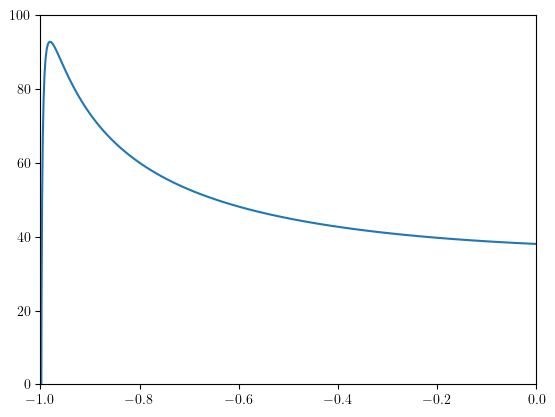

In [15]:
xlist = np.pi/180*np.linspace(90,179.9,num=100)
coslist = np.cos(xlist)

B = []

for x in xlist:
    z = 0.5*(1-np.cos(x))
    cosx = np.cos(x)
    sinx = np.sin(x)

    Blc = Main.Blc_func(z)
    Bnlc= Main.Bnlc_func(z)
    BNf = Main.Blc_func(z)
    B.append(sinx**2*(16/9*Blc+4/9*Bnlc+2*BNf)/4)

plt.ylim([0,100])
plt.xlim([-1,0])
plt.plot(coslist,B)